In [1]:
import data_proc.data_preproc as data_preproc

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
eddy_loader, eddy_loader_val = data_preproc.get_dataloaders(data = "eddy", batch=1)

torch.Size([1, 3, 224, 224])


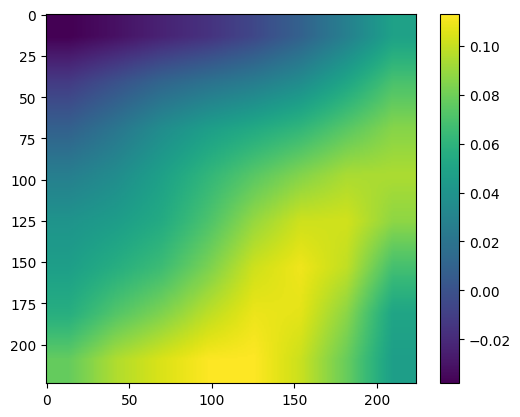

In [7]:
for batch in eddy_loader:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[0][2]

    plt.imshow(img)
    plt.colorbar()
    break

In [16]:
for batch in eddy_loader:
    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    arr = np.array(batch["image"].cpu().numpy())
    arr = np.transpose(arr, (0, 2, 3, 1))
    pixels = arr.reshape(-1, 3)
    print(arr.shape)
    print(pixels.shape)
    break

torch.Size([1, 3, 224, 224])
(1, 224, 224, 3)
(50176, 3)


# fidlin

In [27]:
from tqdm import tqdm
import torch
print()
def std_mean(loader):
    sum_c = np.zeros(3)
    sum_sq_c = np.zeros(3)
    n_pixels = 0

    for batch in tqdm(loader, total=len(loader)):
        x = batch["image"].cpu()
        finite = torch.isfinite(x)
        arr_clean = torch.where(finite, x, torch.zeros_like(x))

        arr = np.array(arr_clean.numpy())
        arr = np.transpose(arr, (0, 2, 3, 1))
        pixels = arr.reshape(-1, 3)



        sum_c += np.nansum(pixels, axis=0) #.sum(axis=0)
        sum_sq_c += (pixels ** 2).sum(axis=0)
        n_pixels += pixels.shape[0]



    mean = sum_c / n_pixels
    var = sum_sq_c / n_pixels - mean ** 2
    var = np.clip(var, a_min=0, a_max=None)
    std = np.sqrt(var)
    #
    # std = np.sqrt(sum_sq_c / n_pixels - mean ** 2)


    print("mean:", mean)
    print("std:", std)

std_mean(eddy_loader)

100%|██████████| 3892/3892 [00:19<00:00, 195.99it/s]

mean: [17.8596782   0.26425405  0.03411109]
std: [7.0410507  0.57394481 0.09307475]


In [27]:
# sealevel = load_pkl(os.path.join("../data/eddy_data/train_images_pkl/20170501/", f"sealevel.pkl"))
#
# CHLA = load_pkl(os.path.join("../data/eddy_data/train_images_pkl/20170501/", f"CHLA.pkl"))
#
# SST = load_pkl(os.path.join("../data/eddy_data/train_images_pkl/20170501/", f"SST.pkl"))
#
# y = load_label_csv(os.path.join(labels_root, f"labels_{20170501}.csv"))

In [6]:
# index = 0
# img = CHLA[index].filled(float(0))
#
# #img = SST[index].filled(float("nan"))
# #img = sealevel[index]
# print(type(img))
# print(img.shape)
#
# img = torch.from_numpy(img).float()
#
# plt.imshow(img, origin="lower", cmap="viridis")
# plt.colorbar()
# plt.show()

NameError: name 'CHLA' is not defined

In [ ]:


# pick the channels you want
channels = ("SST", "CHLA")   # or ("SST","CHLA","sealevel") if you want

train_ds = EddyPatchDataset(images_root, labels_root, train_scene_ids, channels=channels, mean=mean, std=std)
val_ds   = EddyPatchDataset(images_root, labels_root, val_scene_ids,   channels=channels, mean=mean, std=std)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)